# Phase 7: Privacy Constraints

**Goal:** Examine how Apple's App Tracking Transparency (ATT) framework affects uplift modeling, focusing on how model performance degrades as user-level signals are lost and what remains measurable at the aggregate level.

**Input:** `data/df_sample.parquet`, `data/xlearner_scores.parquet`

**Output:** `images/feature_degradation.png`, `images/ablation_controls.png`, `images/threshold_censoring_bias.png`, `images/mde_curve.png`, `images/att_sweep.png`

## Contents
1. Setup
2. Privacy landscape (ATT/SKAN background)
3. Feature loss simulation (KS-ordered ablation)
4. Follow-up experiments (A: variance check; B: outcome dominance test; C: random-order controls; full-scale validation)
5. SKAN threshold censoring (MNAR bias; ATE sign reversal at small cohort sizes)
6. Minimum detectable effect (N_min derivation; 85/15 vs 50/50 allocation penalty)
7. Aggregate incrementality (ATE stability vs CI width across opt-in rates)
8. Summary (what survives ATT)

## 1. Setup

In [1]:
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from scipy.stats import ks_2samp, norm
from lightgbm import LGBMClassifier, LGBMRegressor
from causalml.inference.meta import BaseXClassifier
from sklift.metrics import qini_auc_score, uplift_auc_score

%matplotlib inline
sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.max_columns", None)

## 2. Privacy Landscape

Before iOS 14.5 (2021), advertisers could track individual users across apps via the IDFA, a unique per-device identifier. This enabled user-level attribution and precise targeting. App Tracking Transparency (ATT) ended that: apps must now request explicit permission to read the IDFA, and 70-85% of users decline.

ATT is the constraint this notebook simulates. The practical consequence is that user-level signal is no longer available for the majority of iOS users. Advertisers cannot observe which specific user saw an ad and later converted.

Apple's SKAdNetwork (SKAN) and its successor AdAttributionKit (AAK) are the industry's measurement response to ATT. Their privacy mechanisms reveal what the degradation pattern looks like in practice: data is reported at the cohort level, granularity is tied to cohort size (large volume gets fine data, small volume gets coarsened or nulled data), and no user identifiers are ever transmitted.

This notebook runs three analyses:

- **Sections 3 and 4: Feature loss and mechanism.** Tracking-dependent features disappear progressively as opt-out rates rise; three controlled experiments then identify outcome dominance (not noise or capacity) as the driver and validate the finding at full scale.
- **Section 5: SKAN threshold censoring.** Cohorts whose visit count falls below a privacy threshold are nulled out. This introduces systematic downward bias in the Average Treatment Effect (ATE) estimate, not just wider confidence intervals (CIs).
- **Sections 6 and 7: Statistical power and aggregate measurement.** Section 6 derives the minimum sample size needed to detect the observed effect under the 85/15 allocation. Section 7 estimates the ATE from aggregate holdout data at different ATT opt-in rates.

| Stage | User-level (pre-ATT) | Aggregated (post-ATT) |
|---|---|---|
| Training | Individual feature-label pairs | Cohort-level averages |
| Evaluation | Qini AUC over ranked users | Aggregate lift over coarse segments |
| Deployment | Per-user uplift score | Segment-level targeting rule |

**Note:** while this notebook simulates Apple's ATT/SKAN specifically, the same structural shift (user-level tracking replaced by aggregated, threshold-gated, on-device measurement) is occurring platform-wide: Google's Privacy Sandbox and GDPR-driven consent regimes follow the same paradigm. The degradation patterns quantified here are properties of the aggregation-plus-threshold design itself, not of Apple's implementation.

## 3. Simulating Feature Loss

Load the full sample with all 12 features and reproduce the same train/test split. Features are removed from highest to lowest Kolmogorov-Smirnov (KS) score between the model's predicted persuadable and low-uplift groups. This ordering follows the intuitive reading of KS as feature importance: remove the "most important" features first to trace the steepest expected degradation. Section 4 stress-tests that intuition and finds it fails in an instructive way: KS measures neither uplift value nor clean model reliance. The ablation is therefore best read as a study of what feature loss does to uplift ranking, with the KS ordering as one deliberately chosen (and ultimately misleading) removal schedule, rather than a literal simulation of which features ATT would remove first.

In [2]:
df = pd.read_parquet("../data/df_sample.parquet")
feature_cols = [f"f{i}" for i in range(12)]

stratify_col = df["visit"].astype("str") + "_" + df["treatment"].astype("str")
train_df, test_df = train_test_split(
    df, test_size=0.2, random_state=1, stratify=stratify_col
)
train_df = train_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

scores = pd.read_parquet("../data/xlearner_scores.parquet")
assert (test_df["visit"].values == scores["y_true"].values).all(), "y_true mismatch"
assert (test_df["treatment"].values == scores["treatment"].values).all(), "treatment mismatch"
print(f"Train: {train_df.shape[0]:,}  |  Test: {test_df.shape[0]:,}  |  Alignment verified")

Train: 1,118,366  |  Test: 279,592  |  Alignment verified


In [3]:
n = int(0.10 * len(scores))
persuadables_idx = scores["uplift"].nlargest(n).index
low_uplift_idx   = scores["uplift"].nsmallest(n).index

ks_rows = []
for f in feature_cols:
    result = ks_2samp(test_df.loc[persuadables_idx, f], test_df.loc[low_uplift_idx, f])
    ks_rows.append({"feature": f, "ks_score": round(result.statistic, 4)})

ks_df = (pd.DataFrame(ks_rows)
           .sort_values("ks_score", ascending=False)
           .reset_index(drop=True))
print("Feature KS scores (persuadable vs low-uplift separation):")
ks_df

Feature KS scores (persuadable vs low-uplift separation):


,feature,ks_score
0,f8,0.9989
1,f2,0.9986
2,f9,0.8544
3,f0,0.8235
4,f6,0.5937
5,f3,0.5405
6,f5,0.1703
7,f7,0.1703
8,f4,0.1638
9,f10,0.1638


In [4]:
# frac=0.1 keeps each of the 12 ablation iterations fast; full training set is used in the validation below
train_sub = train_df.sample(frac=0.1, random_state=42).reset_index(drop=True)
print(f"Training subsample: {train_sub.shape[0]:,} rows")

removal_order = ks_df["feature"].tolist()

# light config: fewer trees and higher learning rate to match the subsample scale
lgbm_params = dict(n_estimators=50, num_leaves=31, learning_rate=0.1,
                   random_state=42, verbose=-1, n_jobs=-1)

Training subsample: 111,837 rows


In [5]:
feat_rows = []
for n_removed in range(len(feature_cols)):
    remaining = removal_order[n_removed:]

    X_train = train_sub[remaining].values
    y_train = train_sub["visit"].values
    t_train = train_sub["treatment"].values
    X_test  = test_df[remaining].values

    model = BaseXClassifier(
        outcome_learner=LGBMClassifier(**lgbm_params),
        effect_learner=LGBMRegressor(**lgbm_params),
    )
    model.fit(X_train, t_train, y_train)
    uplift_pred = model.predict(X_test).flatten()

    qini = qini_auc_score(test_df["visit"].values, uplift_pred, test_df["treatment"].values)
    auuc = uplift_auc_score(test_df["visit"].values, uplift_pred, test_df["treatment"].values)

    feat_rows.append({
        "n_features":   len(remaining),
        "last_removed": removal_order[n_removed - 1] if n_removed > 0 else "none",
        "qini_auc":     round(qini, 4),
        "auuc":         round(auuc, 4),
    })
    print(f"n_features={len(remaining):2d}  Qini AUC={qini:.4f}  AUUC={auuc:.4f}")

feat_results = pd.DataFrame(feat_rows)
feat_results

n_features=12  Qini AUC=0.0411  AUUC=0.0161
n_features=11  Qini AUC=0.0542  AUUC=0.0213
n_features=10  Qini AUC=0.0535  AUUC=0.0210
n_features= 9  Qini AUC=0.0601  AUUC=0.0235
n_features= 8  Qini AUC=0.0581  AUUC=0.0228
n_features= 7  Qini AUC=0.0668  AUUC=0.0261
n_features= 6  Qini AUC=0.0235  AUUC=0.0091
n_features= 5  Qini AUC=0.0197  AUUC=0.0076
n_features= 4  Qini AUC=0.0143  AUUC=0.0055
n_features= 3  Qini AUC=0.0051  AUUC=0.0019
n_features= 2  Qini AUC=0.0175  AUUC=0.0068
n_features= 1  Qini AUC=0.0045  AUUC=0.0017


,n_features,last_removed,qini_auc,auuc
0,12,none,0.0411,0.0161
1,11,f8,0.0542,0.0213
2,10,f2,0.0535,0.0210
3,9,f9,0.0601,0.0235
4,8,f0,0.0581,0.0228
5,7,f6,0.0668,0.0261
6,6,f3,0.0235,0.0091
7,5,f5,0.0197,0.0076
8,4,f7,0.0143,0.0055
9,3,f4,0.0051,0.0019


## 4. Model Robustness Under Feature Reduction

Visualize how Qini AUC changes as features are removed in KS order.

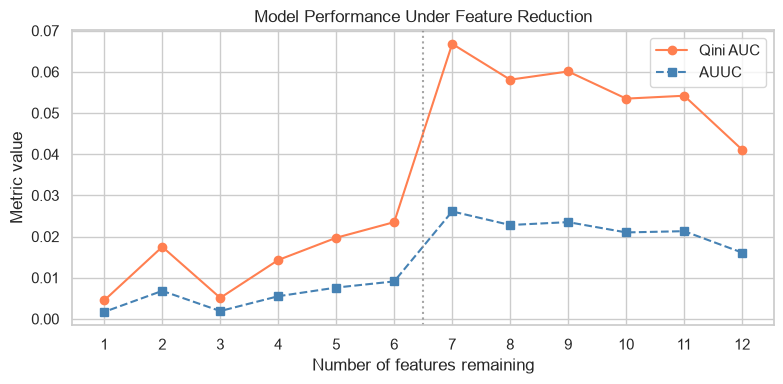

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(feat_results["n_features"], feat_results["qini_auc"],
        marker="o", color="coral", label="Qini AUC")
ax.plot(feat_results["n_features"], feat_results["auuc"],
        marker="s", color="steelblue", linestyle="--", label="AUUC")

ax.axvline(x=6.5, color="gray", linestyle=":", alpha=0.7)
ax.set_xlabel("Number of features remaining")
ax.set_ylabel("Metric value")
ax.set_title("Model Performance Under Feature Reduction")
ax.set_xticks(feat_results["n_features"])
ax.legend()
plt.tight_layout()
plt.savefig("../images/feature_degradation.png", dpi=150, bbox_inches="tight")
plt.show()

Qini AUC gradually improves from 0.0411 to a peak of 0.0668 as features are removed from 12 down to 7, despite the top-KS features being removed first. Removing f8 (KS = 0.999) raises Qini rather than lowering it, suggesting f8 may be a stronger predictor of overall visit probability than of treatment effect. This hypothesis is tested in the follow-up experiments below.

The sharp drop occurs at 6 features (0.0668 to 0.0235) when f3 is removed. At that point only the six weakest features remain (KS below 0.17), and the model loses the ability to separate persuadables from the rest of the population.

### Follow-up: Signal or Noise?

The ablation shows Qini rising as the two highest-KS features (f8, f2) are removed, peaking at 7 features before collapsing. Two hypotheses:

- **H1 (dominance):** f8/f2 monopolize LightGBM splits, ranking users by overall visit probability rather than treatment effect. Removing them forces the model to use a more robust combination of remaining features.
- **H2 (noise):** Under the light config (10% subsample, 50 trees), Qini estimates carry enough variance that the rise is not real. The rebound at n=2 (0.0175 after 0.0051 at n=3) already hints at this.

Three experiments to distinguish them.

**Experiment A: Variance check.** Fit the 12-feature baseline with 3 different training subsamples to estimate the Qini variance band under the light config.

In [7]:
variance_rows = []
for seed in [42, 7, 99]:
    sub = train_df.sample(frac=0.1, random_state=seed).reset_index(drop=True)
    model = BaseXClassifier(
        outcome_learner=LGBMClassifier(**lgbm_params),
        effect_learner=LGBMRegressor(**lgbm_params),
    )
    model.fit(sub[feature_cols].values, sub["treatment"].values, sub["visit"].values)
    uplift_pred = model.predict(test_df[feature_cols].values).flatten()
    qini = qini_auc_score(test_df["visit"].values, uplift_pred, test_df["treatment"].values)
    variance_rows.append({"seed": seed, "qini_auc": round(qini, 4)})
    print(f"seed={seed}  Qini AUC={qini:.4f}")

var_df = pd.DataFrame(variance_rows)
print(f"\nRange: {var_df['qini_auc'].min():.4f} – {var_df['qini_auc'].max():.4f}  "
      f"(spread = {var_df['qini_auc'].max() - var_df['qini_auc'].min():.4f})")

seed=42  Qini AUC=0.0425
seed=7  Qini AUC=0.0456
seed=99  Qini AUC=0.0506

Range: 0.0425 – 0.0506  (spread = 0.0081)


Variance spread = 0.0081 across three seeds. The 0.0257 Qini rise in the KS-ordered ablation is roughly 3x this band, so the counter-intuitive pattern is real signal, not sampling noise.

**Experiment B: Dominance test.** Train two models: one on f8 and f2 only, one on the remaining 10 features. If H1 is correct, the 10-feature model should outperform f8+f2.

In [8]:
top2   = ["f8", "f2"]
other10 = [f for f in feature_cols if f not in top2]

qini_top2 = None
for label, feats in [("f8 + f2 only (2 features)", top2), ("other 10 features", other10)]:
    model = BaseXClassifier(
        outcome_learner=LGBMClassifier(**lgbm_params),
        effect_learner=LGBMRegressor(**lgbm_params),
    )
    model.fit(train_sub[feats].values, train_sub["treatment"].values, train_sub["visit"].values)
    uplift_pred = model.predict(test_df[feats].values).flatten()
    qini = qini_auc_score(test_df["visit"].values, uplift_pred, test_df["treatment"].values)
    auuc = uplift_auc_score(test_df["visit"].values, uplift_pred, test_df["treatment"].values)
    if feats == top2:
        qini_top2 = qini
    print(f"{label:30s}  Qini={qini:.4f}  AUUC={auuc:.4f}")

f8 + f2 only (2 features)       Qini=0.0112  AUUC=0.0044
other 10 features               Qini=0.0535  AUUC=0.0210


The Qini gap between f8+f2 and other10 is consistent with H1, but does not yet explain the mechanism from inside the model. A more direct check: inspect the feature importances of the X-Learner's outcome model (the learner trained on treated users to predict visit probability). If the outcome model assigns high importance to f8 and f2, it means the X-Learner is spending splits on outcome prediction rather than treatment effect estimation, which is exactly the dominance failure mode.

In [9]:
# retrain 12-feature model on train_sub to access the outcome learner internals
model_12 = BaseXClassifier(
    outcome_learner=LGBMClassifier(**lgbm_params),
    effect_learner=LGBMRegressor(**lgbm_params),
)
model_12.fit(train_sub[feature_cols].values, train_sub["treatment"].values, train_sub["visit"].values)

# models_mu_t is keyed by treatment group label (1), not by position
imp_df = (
    pd.DataFrame({
        "feature":    feature_cols,
        "outcome_importance": model_12.models_mu_t[1].feature_importances_,
    })
    .merge(ks_df, on="feature")
    .sort_values("outcome_importance", ascending=False)
    .reset_index(drop=True)
)
imp_df

,feature,outcome_importance,ks_score
0,f2,348,0.9986
1,f0,251,0.8235
2,f8,237,0.9989
3,f6,234,0.5937
4,f9,131,0.8544
5,f3,92,0.5405
6,f7,67,0.1703
7,f10,61,0.1638
8,f4,33,0.1638
9,f11,19,0.0515


The outcome model does not rely exclusively on f8 and f2: f2 leads (importance 348), but f0 (251) and f6 (234) contribute as much as f8 (237).

The KS column exposes the disconnect: f0 ranks second in importance yet scores KS=0.82, while f8, with lower importance, scores 0.999. Outcome importance alone therefore cannot explain KS; the near-perfect scores of f8/f2 likely also reflect how the score-based group cut interacts with these features' value distributions. Either way, this confirms KS is a poor importance measure: it conflates model reliance with distributional artifacts, and neither component measures uplift signal.

The feature importance shows the outcome model relies on f8 and f2 substantially. A direct quantification: measure their area under the receiver operating characteristic curve (ROC AUC) when used alone to predict visit probability.

In [10]:
outcome_clf = LGBMClassifier(**lgbm_params)
outcome_clf.fit(train_sub[top2].values, train_sub["visit"].values)
visit_prob = outcome_clf.predict_proba(test_df[top2].values)[:, 1]
roc_auc_top2 = roc_auc_score(test_df["visit"].values, visit_prob)

print(f"f8+f2 outcome classifier  ROC AUC: {roc_auc_top2:.4f}")
print(f"f8+f2 uplift X-Learner    Qini:    {qini_top2:.4f}")

f8+f2 outcome classifier  ROC AUC: 0.9372
f8+f2 uplift X-Learner    Qini:    0.0112


f8+f2 as outcome classifiers: ROC AUC = 0.9372 on visit prediction. As uplift features: Qini = 0.0112, near random. The gap between these two metrics is direct evidence of the dominance mechanism: these features rank users by visit likelihood, not by response to treatment. This is a feature-level instance of the field's first lesson: response models are not uplift models.

**Experiment C: Random-order controls.** Rerun the ablation at 6 checkpoints (n=12,10,8,6,4,2) with five random feature removal orders. If the KS-ordered curve is uniquely shaped while random curves show no consistent pattern, H1 wins. If all curves fluctuate similarly, H2 wins.

In [11]:
checkpoints = [12, 10, 8, 6, 4, 2]

def run_ablation_checkpoints(order):
    print(f"  {'n_features':>10}  {'Qini AUC':>8}")
    print(f"  {'-'*10}  {'-'*8}")
    rows = []
    for n_feat in checkpoints:
        n_removed = len(order) - n_feat
        remaining = order[n_removed:]
        model = BaseXClassifier(
            outcome_learner=LGBMClassifier(**lgbm_params),
            effect_learner=LGBMRegressor(**lgbm_params),
        )
        model.fit(train_sub[remaining].values, train_sub["treatment"].values, train_sub["visit"].values)
        uplift_pred = model.predict(test_df[remaining].values).flatten()
        qini = qini_auc_score(test_df["visit"].values, uplift_pred, test_df["treatment"].values)
        rows.append({"n_features": n_feat, "qini_auc": round(qini, 4)})
        print(f"  {n_feat:>10}  {qini:>8.4f}")
    return pd.DataFrame(rows)

In [12]:
rand_orders = {
    seed: np.random.default_rng(seed).permutation(feature_cols).tolist()
    for seed in range(1, 6)
}

for seed, order in rand_orders.items():
    print(f"Random order {seed} (removed first → last): {order}")

rand_results = {}
for seed, order in rand_orders.items():
    print(f"\nRandom order {seed}:")
    rand_results[seed] = run_ablation_checkpoints(order)

Random order 1 (removed first → last): ['f8', 'f11', 'f4', 'f7', 'f5', 'f0', 'f1', 'f9', 'f2', 'f10', 'f6', 'f3']
Random order 2 (removed first → last): ['f2', 'f0', 'f9', 'f10', 'f11', 'f7', 'f5', 'f6', 'f3', 'f4', 'f8', 'f1']
Random order 3 (removed first → last): ['f11', 'f7', 'f2', 'f10', 'f0', 'f1', 'f4', 'f6', 'f9', 'f5', 'f3', 'f8']
Random order 4 (removed first → last): ['f1', 'f0', 'f8', 'f2', 'f10', 'f9', 'f7', 'f6', 'f4', 'f3', 'f5', 'f11']
Random order 5 (removed first → last): ['f9', 'f11', 'f1', 'f3', 'f2', 'f4', 'f6', 'f7', 'f0', 'f10', 'f5', 'f8']

Random order 1:
  n_features  Qini AUC
  ----------  --------
          12    0.0389
          10    0.0507
           8    0.0461
           6    0.0404
           4    0.0535
           2    0.0581

Random order 2:
  n_features  Qini AUC
  ----------  --------
          12    0.0399
          10    0.0463
           8    0.0517
           6    0.0534
           4    0.0610
           2    0.0202

Random order 3:
  n_feature

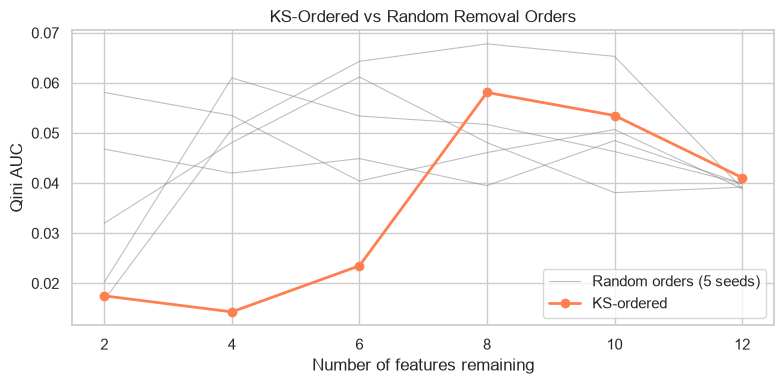

In [13]:
ks_checkpoints = feat_results[feat_results["n_features"].isin(checkpoints)].copy()

fig, ax = plt.subplots(figsize=(8, 4))

for seed, rdf in rand_results.items():
    ax.plot(rdf["n_features"], rdf["qini_auc"],
            color="gray", linewidth=0.8, alpha=0.5,
            label="Random orders (5 seeds)" if seed == 1 else "_nolegend_")

ax.plot(ks_checkpoints["n_features"], ks_checkpoints["qini_auc"],
        marker="o", color="coral", linewidth=2, label="KS-ordered")

ax.set_xlabel("Number of features remaining")
ax.set_ylabel("Qini AUC")
ax.set_title("KS-Ordered vs Random Removal Orders")
ax.set_xticks(checkpoints)
ax.legend()
plt.tight_layout()
plt.savefig("../images/ablation_controls.png", dpi=150, bbox_inches="tight")
plt.show()

Four of five random curves peak clearly above the 12-feature baseline (0.0411). Order 3 is the exception: its peak of 0.0485 is only 0.0074 above baseline, inside the ±0.0081 noise band from Experiment A, so its gains are indistinguishable from variance. Order 3 keeps f8 until the final position, meaning a dominant feature is always present throughout its ablation.

The other four curves expose the dominant set more precisely. Order 5 removes f9 first while f2 and f8 remain, and peaks at 0.0678 at n=8 (the highest Qini of any random curve) just from f9's removal. Order 4 removes f8 and f2 at positions 3 and 4, but Qini at n=8 (once they are gone) is still 0.0481; the peak of 0.0612 at n=6 arrives only after f9 also exits at position 6. Both orders identify f9 as part of the dominant set: {f8, f2, f9} share the three highest KS scores (0.999, 0.999, 0.854) and removing any of them individually lifts performance.

The n=2 endpoints span 0.017 to 0.058, determined entirely by which two features survive. Order 1 ends with [f6, f3], the two moderate uplift-signal features, producing Qini 0.058. Order 2 ends with [f8, f1] (dominant outcome feature paired with the weakest feature), producing Qini 0.020.

The KS-ordered cliff at n=7→6 is sharper than any random curve because the ordering systematically exhausts all moderately-informative features at that single step, leaving only the six weakest. Random orders scatter that drop across different checkpoints.

All three experiments converge on H1. The ablation rise is real, not noise (Experiment A). f8 and f2 are outcome predictors that crowd out treatment effect signal, confirmed three independent ways: Qini gap, feature importance, and ROC AUC (Experiment B). Four of five random curves peak clearly above the 12-feature baseline when dominant features are stripped by chance; the fifth keeps f8 throughout and shows no clear gain, consistent with the dominance mechanism (Experiment C). Throughout, the KS ranking procedure is circular: it measures how strongly a feature separates the model's own predicted groups, which validates the model's existing biases rather than genuine uplift signal.

### Full-Scale Validation of the Dominance Finding

The ablation used a light config (10% subsample, 50 trees), so the finding that removing f8 and f2 improves Qini needs validation at full scale before drawing conclusions. Train on the full training set with the original notebook-3 hyperparameters and compare against the 12-feature baseline (Qini = 0.0760, Area Under the Uplift Curve (AUUC) = 0.0299).

In [14]:
# full_params matches notebook-3 hyperparameters used for the 12-feature baseline (Qini=0.0760)
full_params = dict(n_estimators=100, learning_rate=0.05, num_leaves=31,
                   random_state=42, verbose=-1, n_jobs=-1)

features_10 = [f for f in feature_cols if f not in ["f8", "f2"]]

model_full = BaseXClassifier(
    outcome_learner=LGBMClassifier(**full_params),
    effect_learner=LGBMRegressor(**full_params),
)
model_full.fit(
    train_df[features_10].values,
    train_df["treatment"].values,
    train_df["visit"].values,
)
uplift_10 = model_full.predict(test_df[features_10].values).flatten()

qini_10 = qini_auc_score(test_df["visit"].values, uplift_10, test_df["treatment"].values)
auuc_10  = uplift_auc_score(test_df["visit"].values, uplift_10, test_df["treatment"].values)

print(f"{'Model':<25} {'Qini AUC':>10} {'AUUC':>10}")
print("-" * 47)
print(f"{'12-feature baseline':<25} {0.0760:>10.4f} {0.0299:>10.4f}")
print(f"{'10-feature (no f8/f2)':<25} {qini_10:>10.4f} {auuc_10:>10.4f}")

Model                       Qini AUC       AUUC
-----------------------------------------------
12-feature baseline           0.0760     0.0299
10-feature (no f8/f2)         0.0707     0.0277


The dominance effect is regime-dependent.

Under the light config (10% subsample, 50 trees), removing f8 and f2 improves Qini by roughly 60% (0.0411 to a peak of 0.0668 at 7 features). At full scale (full training set, 100 trees), removing them costs 7% (0.0760 to 0.0707). With ample data and capacity the model exploits f8 and f2 safely, balancing them against the remaining features. Under constrained conditions those same features crowd out treatment-effect signal and degrade uplift ranking.

This connects directly to the notebook's privacy theme. ATT-era conditions (feature censoring, aggregated training data, smaller effective cohorts) are precisely capacity-constrained regimes. Feature dominance harm that is invisible at full scale becomes a real problem when data degrades, making feature selection more important as privacy constraints tighten, not less.

One honest note on the full-scale result: f8 and f2 have the two highest KS scores (≈0.999), yet removing them at full scale only costs 7% Qini. High KS predicted they would be the most important features; ablation says their actual contribution is small. This is the circularity in concrete numbers: KS measures model reliance, not uplift value.

## 5. SKAN Threshold Censoring

Sections 6 and 7 will show that as cohort size shrinks, the ATE estimate stays unbiased but CIs widen (sampling degradation, a variance problem). Threshold censoring is different in kind.

SKAN nulls out any reporting unit whose conversion count falls below a privacy threshold t. Because low-conversion cohorts are dropped systematically, the surviving cohorts in each arm have inflated average visit rates. This is a Missing Not At Random (MNAR) mechanism: the data is missing precisely because the signal was weak. The result is bias in the ATE estimate, not just wider CIs.

This experiment maps directly onto two entries in the SKAN privacy mechanism table: k (cohort size) controls crowd anonymity aggregation, and t (minimum visit count to survive) controls the privacy threshold. The simulation splits by treatment arm before forming cohorts so each cohort is purely treatment or purely control, consistent with how SKAN campaign-level postbacks are structured.

In [15]:
def make_cohorts(visit_values, k, seed):
    # randomly partition users into cohorts of size k, return per-cohort visit counts
    rng = np.random.default_rng(seed)
    idx = rng.permutation(len(visit_values))
    shuffled = visit_values[idx]
    n_cohorts = len(shuffled) // k
    return np.array([shuffled[i*k:(i+1)*k].sum() for i in range(n_cohorts)])

In [16]:
t_visits = test_df[test_df["treatment"] == 1]["visit"].values
c_visits  = test_df[test_df["treatment"] == 0]["visit"].values
true_ate_skan = 0.0103

k_values = [50, 100, 500]      # cohort sizes: small, medium, large
t_values = [0, 1, 3, 5, 10]   # privacy thresholds; t=0 is the no-censoring sanity check

rows = []
for k in k_values:
    t_counts = make_cohorts(t_visits, k, seed=k * 10 + 1)
    c_counts  = make_cohorts(c_visits,  k, seed=k * 10 + 2)
    n_total   = len(t_counts) + len(c_counts)

    for t in t_values:
        t_surv = t_counts[t_counts >= t]  # cohorts surviving the threshold
        c_surv = c_counts[c_counts >= t]

        if len(t_surv) > 0 and len(c_surv) > 0:
            t_rate  = t_surv.sum() / (len(t_surv) * k)  # visit rate among survivors
            c_rate  = c_surv.sum() / (len(c_surv) * k)
            ate_est = t_rate - c_rate
        else:
            ate_est = np.nan

        pct_lost = 1 - (len(t_surv) + len(c_surv)) / n_total

        rows.append({
            "k":               k,
            "t":               t,
            "ate_est":         round(ate_est, 4),
            "pct_users_lost":  round(pct_lost, 3),
        })

skan_df = pd.DataFrame(rows)
skan_df

,k,t,ate_est,pct_users_lost
0,50,0,0.0103,0.000
1,50,1,0.0081,0.093
2,50,3,0.0057,0.578
3,50,5,-0.0010,0.907
4,50,10,NaN,1.000
5,100,0,0.0103,0.000
6,100,1,0.0097,0.005
7,100,3,0.0076,0.145
8,100,5,0.0048,0.491
9,100,10,0.0081,0.981


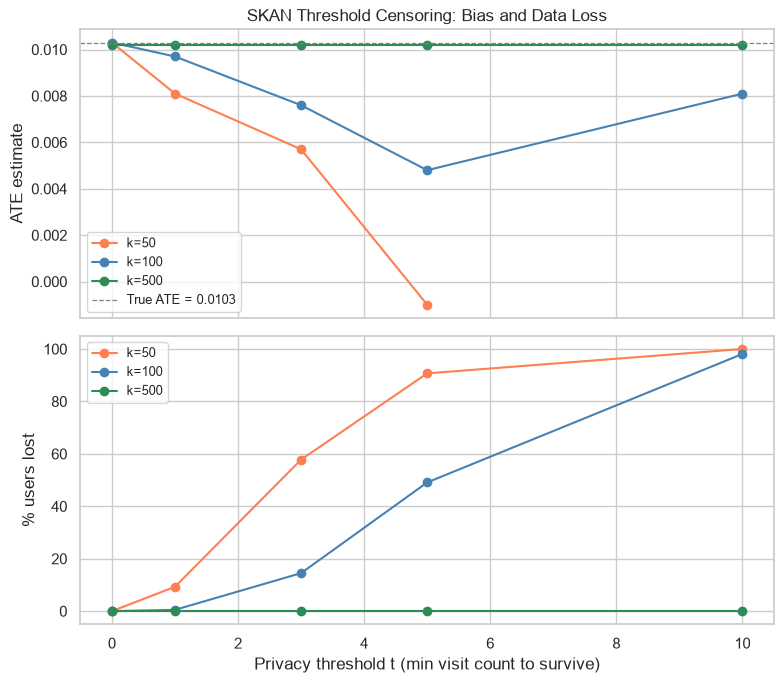

In [17]:
colors = {50: "coral", 100: "steelblue", 500: "seagreen"}

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 7), sharex=True)

for k in k_values:
    kdf = skan_df[skan_df["k"] == k]
    ax1.plot(kdf["t"], kdf["ate_est"],        marker="o", color=colors[k], label=f"k={k}")
    ax2.plot(kdf["t"], kdf["pct_users_lost"] * 100, marker="o", color=colors[k], label=f"k={k}")

ax1.axhline(true_ate_skan, color="gray", linestyle="--", linewidth=0.9, label=f"True ATE = {true_ate_skan}")
ax1.set_ylabel("ATE estimate")
ax1.set_title("SKAN Threshold Censoring: Bias and Data Loss")
ax1.legend(fontsize=9)

ax2.set_xlabel("Privacy threshold t (min visit count to survive)")
ax2.set_ylabel("% users lost")
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig("../images/threshold_censoring_bias.png", dpi=150, bbox_inches="tight")
plt.show()

**Sanity check (t=0):** all three k values recover ATE=0.0103, confirming that cohort aggregation without censoring is lossless.

**k=500 (immune):** ATE holds at 0.0102 across every threshold, including t=10. Expected visit counts per cohort are ~24 (treatment) and ~19 (control), both well above t=10, so zero cohorts are censored at any threshold tested.

**k=100 (moderate degradation):** ATE drops monotonically from 0.0097 to 0.0048 (53% downward bias) as t rises from 1 to 5, with data loss growing from 0.5% to 49%. At t=10 the estimate jumps back to 0.0081 despite 98% data loss (survivor-bias artifact: only the 2% of extreme outlier cohorts remain, and their relative enrichment in both arms happens to partially restore the ATE estimate). This t=10 point should not be read as recovery; it represents a nearly empty dataset.

**k=50 (catastrophic):** ATE collapses from 0.0103 to -0.0010 (sign reversal) by t=5 with 90.7% data loss, then hits NaN at t=10. Expected visit count per cohort is only ~2.4 (treatment) and ~1.9 (control). A threshold of t=5 is more than twice the expected count, censoring nearly every cohort. The control arm (lower base rate) loses proportionally more cohorts than treatment, inflating C_estimated faster than T_estimated until the estimated control rate exceeds the estimated treatment rate.

| k | t=1 | t=3 | t=5 | t=10 |
|---|---|---|---|---|
| 500 | 0.0102 (0%) | 0.0102 (0%) | 0.0102 (0%) | 0.0102 (0%) |
| 100 | 0.0097 (0.5%) | 0.0076 (14.5%) | 0.0048 (49.1%) | 0.0081* (98.1%) |
| 50 | 0.0081 (9.3%) | 0.0057 (57.8%) | -0.0010 (90.7%) | NaN (100%) |

ATE estimate (% users lost). *Survivor-bias artifact.

**Methodology note:** each (k, t) cell uses a single random partition. Estimates in the high-censoring regime (k=50, t≥5) carry partition variability and should be read as illustrative rather than precise.

## 6. Minimum Detectable Effect

Compute the minimum uplift effect size detectable at 80% power across a range of sample sizes, reflecting the smaller signals available under aggregated measurement.

In [18]:
# observed_ate = 0.0103 matches the ITT ATE from notebook 1
# (treatment visit rate 0.0485 - control visit rate 0.0382 on the full test set)
p_base          = 0.047
treatment_ratio = 0.85
observed_ate    = 0.0103
z_alpha = norm.ppf(1 - 0.05 / 2)
z_beta  = norm.ppf(0.80)

# N_min = (z_alpha + z_beta)^2 * p*(1-p) * (1/k + 1/(1-k)) / ATE^2
k = treatment_ratio
N_min = (z_alpha + z_beta)**2 * p_base * (1 - p_base) * (1/k + 1/(1 - k)) / observed_ate**2
print(f"Minimum N to detect ATE={observed_ate} (85/15 allocation): {int(np.ceil(N_min)):,}")

Minimum N to detect ATE=0.0103 (85/15 allocation): 25,991


In [19]:
sample_sizes = [1_000, 5_000, 10_000, 25_000, 50_000, 100_000, 500_000, 1_000_000]
rows = []
for N in sample_sizes:
    n_t      = k * N
    n_c      = (1 - k) * N
    mde      = (z_alpha + z_beta) * np.sqrt(p_base * (1 - p_base) * (1/n_t + 1/n_c))
    mde_5050 = (z_alpha + z_beta) * np.sqrt(p_base * (1 - p_base) * (1/(0.5*N) + 1/(0.5*N)))
    rows.append({
        "total_users":  N,
        "n_treatment":  int(n_t),
        "n_control":    int(n_c),
        "mde_85_15":    round(mde, 5),
        "mde_50_50":    round(mde_5050, 5),
        "detects_ate":  mde < observed_ate,
    })

mde_df = pd.DataFrame(rows)
penalty = mde_df["mde_85_15"].iloc[0] / mde_df["mde_50_50"].iloc[0]
print(f"MDE penalty of 85/15 vs 50/50 allocation: {penalty:.2f}x  (~2x sample needed for equal power)")
print(f"Observed ATE = {observed_ate}")
mde_df

MDE penalty of 85/15 vs 50/50 allocation: 1.40x  (~2x sample needed for equal power)
Observed ATE = 0.0103


,total_users,n_treatment,n_control,mde_85_15,mde_50_50,detects_ate
0,1000,850,150,0.05251,0.03750,False
1,5000,4250,750,0.02348,0.01677,False
2,10000,8500,1500,0.01661,0.01186,False
3,25000,21250,3750,0.01050,0.00750,False
4,50000,42500,7500,0.00743,0.00530,True
5,100000,85000,15000,0.00525,0.00375,True
6,500000,425000,75000,0.00235,0.00168,True
7,1000000,850000,150000,0.00166,0.00119,True


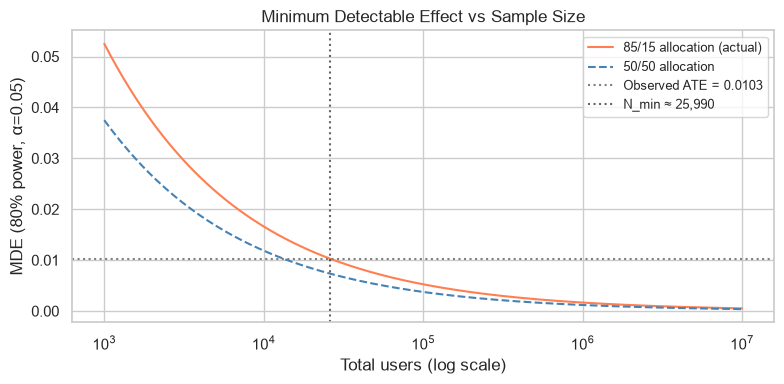

In [20]:
n_range = np.logspace(3, 7, 300)
mde_range_8515 = (z_alpha + z_beta) * np.sqrt(
    p_base * (1 - p_base) * (1/(k * n_range) + 1/((1 - k) * n_range))
)
mde_range_5050 = (z_alpha + z_beta) * np.sqrt(
    p_base * (1 - p_base) * (2 / (0.5 * n_range) )
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(n_range, mde_range_8515, color="coral",     label="85/15 allocation (actual)")
ax.plot(n_range, mde_range_5050, color="steelblue", linestyle="--", label="50/50 allocation")
ax.axhline(observed_ate, color="gray",  linestyle=":", label=f"Observed ATE = {observed_ate}")
ax.axvline(N_min,        color="black", linestyle=":", alpha=0.6, label=f"N_min ≈ {int(N_min):,}")
ax.set_xscale("log")
ax.set_xlabel("Total users (log scale)")
ax.set_ylabel("MDE (80% power, α=0.05)")
ax.set_title("Minimum Detectable Effect vs Sample Size")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("../images/mde_curve.png", dpi=150, bbox_inches="tight")
plt.show()

### Privacy Timeline as a Measurement Statement

The minimum sample size (N_min = 25,991) turns the privacy timeline into a measurement statement.

In the IDFA era, advertisers pooled tens of millions of user-level observations, placing campaigns far to the right of N_min where even sub-1% effects were detectable. ATT reduced user-level measurement to the 15-30% of users who opt into tracking (industry-reported range), pushing fine-grained analyses toward the threshold. Under SKAN, measurement units fragment into campaign x geo x time cells, each typically holding 10^3 to 10^4 users (illustrative order of magnitude, not derived from this dataset), one to two orders of magnitude below N_min. At that scale, an effect of this size (roughly 1 percentage point visit uplift) is statistically invisible per cell; detection is only possible by re-aggregating cells, which is exactly the trade Apple's framework is designed to enforce: measurement survives only at the aggregate.

N_min is the sample size where MDE equals the observed ATE exactly. Below N_min the MDE exceeds the ATE, meaning the true effect is too small for the experiment to distinguish from noise at 80% power. Above N_min the MDE falls below the ATE and the effect becomes reliably detectable.

The mde_df table above shows this crossing directly. At N=25,000 the 85/15 MDE is 0.0105, just above the ATE of 0.0103 (underpowered by a narrow margin). At N=50,000 it drops to 0.0074, safely below (adequately powered). The closed-form N_min of 25,991 falls between these two checkpoints, consistent with both.

The bottleneck throughout is the 15% control allocation: at N=25,000 the control group has only 3,750 users, which is too small to estimate the control visit rate precisely enough. Under a balanced 50/50 split the same detection threshold would require roughly 13,300 users; the 85/15 imbalance raises that to 25,991, a ~2x penalty (the 1.4x MDE penalty squared, since MDE ∝ 1/sqrt(N)).

Under ATT with 20% opt-in, a campaign needs approximately 130,000 iOS users to field a detectable holdout experiment (25,991 / 0.20). For smaller campaigns, aggregate incrementality becomes statistically unreliable before it becomes conceptually unavailable.

## 7. Aggregate-Level Incrementality

Simulate group-level uplift estimation using holdout experiments and compare to user-level estimates, showing what is still recoverable without individual attribution.

In [21]:
def bootstrap_ate(df, n_resamples=1000, seed=42):
    rng  = np.random.default_rng(seed)
    n    = len(df)
    ates = np.empty(n_resamples)
    for i in range(n_resamples):
        idx      = rng.integers(0, n, size=n)
        sample   = df.iloc[idx]
        ates[i]  = (sample[sample["treatment"] == 1]["visit"].mean()
                  - sample[sample["treatment"] == 0]["visit"].mean())
    return np.percentile(ates, [2.5, 97.5])

In [22]:
# full cohort
full_ate      = (test_df[test_df["treatment"] == 1]["visit"].mean()
               - test_df[test_df["treatment"] == 0]["visit"].mean())
full_ci       = bootstrap_ate(test_df)
full_ci_width = full_ci[1] - full_ci[0]

# ATT cohort: simulate 20% opt-in by random subsample
att_df        = test_df.sample(frac=0.20, random_state=42)
att_ate       = (att_df[att_df["treatment"] == 1]["visit"].mean()
               - att_df[att_df["treatment"] == 0]["visit"].mean())
att_ci        = bootstrap_ate(att_df)
att_ci_width  = att_ci[1] - att_ci[0]

print(f"Full cohort  (N={len(test_df):,}):  ATE={full_ate:.4f}  95% CI [{full_ci[0]:.4f}, {full_ci[1]:.4f}]  width={full_ci_width:.4f}")
print(f"ATT cohort   (N={len(att_df):,}):  ATE={att_ate:.4f}  95% CI [{att_ci[0]:.4f}, {att_ci[1]:.4f}]  width={att_ci_width:.4f}")
print(f"\nCI width ratio: {att_ci_width / full_ci_width:.2f}x wider at 20% opt-in")

Full cohort  (N=279,592):  ATE=0.0103  95% CI [0.0084, 0.0124]  width=0.0040
ATT cohort   (N=55,918):  ATE=0.0101  95% CI [0.0057, 0.0142]  width=0.0085

CI width ratio: 2.13x wider at 20% opt-in


In [23]:
fracs = [1.0, 0.5, 0.3, 0.2, 0.1, 0.05]
sweep_rows = []
for frac in fracs:
    sub          = test_df if frac == 1.0 else test_df.sample(frac=frac, random_state=42)
    ate_val      = (sub[sub["treatment"] == 1]["visit"].mean()
                  - sub[sub["treatment"] == 0]["visit"].mean())
    ci_lo, ci_hi = bootstrap_ate(sub)
    sweep_rows.append({
        "opt_in_frac":     frac,
        "n_total":         len(sub),
        "ate":             round(ate_val, 4),
        "ci_lo":           round(ci_lo, 4),
        "ci_hi":           round(ci_hi, 4),
        "ci_crosses_zero": ci_lo < 0,
    })

sweep_df = pd.DataFrame(sweep_rows)
print(sweep_df.to_string(index=False))

# first frac (descending) where CI crosses zero
crossing_fracs = sweep_df[sweep_df["ci_crosses_zero"]]["opt_in_frac"]
first_crossing = crossing_fracs.max() if not crossing_fracs.empty else None
n_min_frac     = N_min / len(test_df)
print(f"\nCI first crosses zero at opt-in frac: {first_crossing}")
print(f"N_min implied opt-in frac:            {n_min_frac:.3f}  (N_min={int(N_min):,} / {len(test_df):,})")

 opt_in_frac  n_total    ate   ci_lo  ci_hi  ci_crosses_zero
        1.00   279592 0.0103  0.0084 0.0124            False
        0.50   139796 0.0107  0.0079 0.0137            False
        0.30    83878 0.0105  0.0066 0.0142            False
        0.20    55918 0.0101  0.0057 0.0142            False
        0.10    27959 0.0095  0.0033 0.0158            False
        0.05    13980 0.0067 -0.0022 0.0158             True

CI first crosses zero at opt-in frac: 0.05
N_min implied opt-in frac:            0.093  (N_min=25,990 / 279,592)


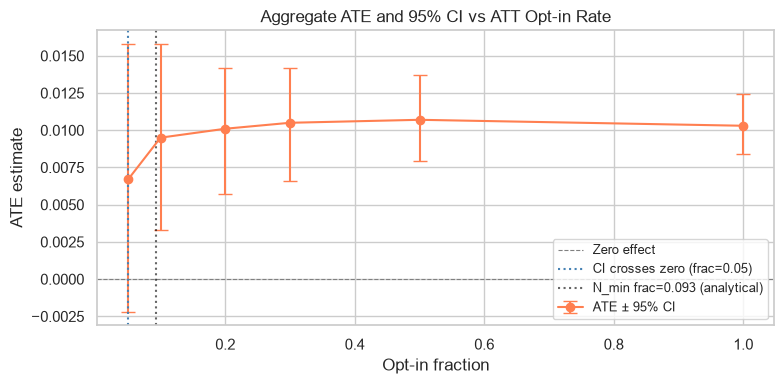

In [24]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.errorbar(sweep_df["opt_in_frac"], sweep_df["ate"],
            yerr=[sweep_df["ate"] - sweep_df["ci_lo"],
                  sweep_df["ci_hi"] - sweep_df["ate"]],
            fmt="o-", color="coral", capsize=5, label="ATE ± 95% CI")
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8, label="Zero effect")
if first_crossing is not None:
    ax.axvline(first_crossing, color="steelblue", linestyle=":",
               label=f"CI crosses zero (frac={first_crossing})")
ax.axvline(n_min_frac, color="black", linestyle=":", alpha=0.6,
           label=f"N_min frac={n_min_frac:.3f} (analytical)")
ax.set_xlabel("Opt-in fraction")
ax.set_ylabel("ATE estimate")
ax.set_title("Aggregate ATE and 95% CI vs ATT Opt-in Rate")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("../images/att_sweep.png", dpi=150, bbox_inches="tight")
plt.show()

The point estimate is stable across opt-in rates (0.0095 to 0.0107 across all fracs), but the CI widens substantially. At full scale the 95% CI is [0.0084, 0.0124] (width = 0.0040). At 20% opt-in it is [0.0057, 0.0142] (width = 0.0085), a 2.13x increase with both bounds still positive. At 5% opt-in (N = 13,980) the lower bound first goes negative (CI = [-0.0022, 0.0158]), making the effect statistically indistinguishable from zero.

The crossing is consistent with section 6's analytical threshold: N_min = 25,991 corresponds to an opt-in fraction of 0.093, which lies between the frac=0.10 checkpoint (N=27,959, CI still positive at [0.0033, 0.0158]) and frac=0.05 (N=13,980, CI crosses zero). Both the power formula and the bootstrap sweep converge on the same detection boundary.

**Limitation:** random subsampling simulates only the sample-size effect of ATT. It assumes opt-in users are a random subset of all users, preserving the treatment/control ratio and the visit rate distribution. In practice, users who opt into tracking likely differ systematically from those who do not (younger, more app-engaged, higher baseline visit rates). This selection bias would shift the ATE estimate in the opted-in cohort away from the true population ATE. The results here are therefore a lower bound on measurement damage: degradation in practice will be larger than the CI widening shown above.

## 8. Summary

Three mechanisms. Each degrades measurement differently.

**Feature loss (sections 3 and 4)**
- Removing high-KS features counterintuitively *improved* uplift ranking (Qini +60% under the light config) before collapsing when the last informative feature was removed.
- Three experiments traced the cause to **outcome dominance**: f8 and f2 are strong visit predictors (ROC AUC 0.94 together) but near-random as uplift features (Qini 0.011); the random-order controls implicate f9 as a third dominant feature. They monopolize model splits and crowd out treatment-effect signal.
- The effect is **regime-dependent**: at full scale, removing them costs 7% Qini rather than gaining. Dominance harm activates in data-constrained conditions, exactly where ATT pushes campaigns.

**SKAN threshold censoring (section 5)**
- Censoring is MNAR: cohorts are dropped because their visit count is low, not at random.
- The control arm (lower base visit rate) loses cohorts faster, systematically compressing the ATE estimate downward.
- At small cohort sizes (k=50), a moderate threshold (t=5) is enough to flip the sign of the measured effect entirely.

**Statistical power and aggregate measurement (sections 6 and 7)**
- Detecting the observed effect requires roughly 26,000 users; the 85/15 allocation raises this ~2x vs a balanced experiment (the 1.4x MDE penalty squared).
- Aggregate ATE remains unbiased across opt-in rates, but CI width grows 2.1x at 20% opt-in and the effect becomes statistically invisible below roughly 5% opt-in.

**What survives ATT:**

| Capability | Pre-ATT | Post-ATT | Evidence |
|---|---|---|---|
| Per-user uplift ranking | Works | Breaks as features are lost | Sections 3-4 |
| CATE-based budget policy | Works | Degrades in data-constrained regimes | Section 4 |
| Aggregate incrementality | Works | Survives above N_min; biased under threshold censoring | Sections 5-7 |